<a href="https://colab.research.google.com/github/liliannakakaawa/iris-streamlit-app-lilian/blob/main/Python_C2_07_Data_visualization_using_t_SNE_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Welcome Back to Python Course 2!**

In the previous lesson, we covered how to perform Machine learning. We also learned the syntax for writing functions. If you haven't completed these topics, please refer to L06 - Machine Learning: Classification before practicing the codes for this lesson.

# **Let's Recap!**

Now that we've covered essential concepts in [L07 - Data visualization using t-SNE & UMAP](https://learn.omicslogic.com/Python/python-course-2-introduction-to-data-science-bioml/lesson/07-data-visualization-using-t-sne-and-umap), let's take a moment to reinforce what we've learned so far. We'll start with a brief recap of the codes and techniques we've explored in the lesson.

**t-Distributed Stochastic Neighbor Embedding (t-SNE)** is a popular dimensionality reduction technique used primarily for visualizing high-dimensional data. It excels in preserving local structures, making it effective for identifying clusters or groups within data. t-SNE works by converting similarities between data points to probabilities and minimizing the divergence between these probabilities in both the original and reduced spaces.

# **Lesson Code Breakdown**

## **1. Load and prepare data**

In [ ]:
import pandas as pd

df = df = pd.read_csv('https://reneshbedre.github.io/assets/posts/tsne/ath_root_sub_seurat_processes.csv')
df = df.set_index(df.columns[0])
dft = df.T
dft = dft.set_index(dft.columns[0])

# check data
dft.head()

gene,RPP1A,HTR12,AT1G01453,ADF10,PLIM2B,SBTI1.1,GL22,GPAT2,AT1G02570,BXL2,...,AT5G66440,AT5G66580,AT5G66590,AT5G66800,AT5G66815,AT5G66860,AT5G66985,IRX14H,PER73,RPL26B
AT1G01070,,,,,,,,,,,,,,,,,,,,,
0.51,1.40,-0.26,-0.28,-0.24,-0.14,-0.13,-0.07,-0.29,-0.31,-0.23,...,0.61,-0.55,-0.41,-0.43,2.01,3.01,-0.24,-0.18,-0.34,1.16
-0.22,1.36,-0.26,-0.28,-0.60,-0.51,-0.13,-0.07,-0.29,-0.31,0.81,...,-0.48,-0.55,-0.41,-0.43,-0.24,0.89,-0.24,-0.18,-0.49,-0.68
-0.22,2.49,-0.26,-0.28,-0.60,-0.51,-0.13,-0.07,-0.29,-0.31,-0.23,...,-0.48,-0.55,2.92,-0.43,-0.24,2.82,-0.24,-0.18,-0.49,1.60
2.24,0.82,-0.26,-0.28,-0.60,-0.51,-0.13,-0.07,-0.29,-0.31,-0.23,...,0.91,-0.55,-0.41,-0.43,-0.24,-0.43,-0.24,-0.18,-0.49,1.95
-0.22,-0.51,-0.26,-0.28,-0.60,-0.51,-0.13,-0.07,-0.29,-0.31,-0.23,...,-0.48,1.85,-0.41,-0.43,-0.24,-0.43,8.85,-0.18,-0.49,0.16



This code snippets imports a CSV file into a DataFrame df using Pandas, then sets its first column as the index. It then transposes this DataFrame into dft, setting the first column of the transposed DataFrame as its index too. The dft.head() function is used to display the first five rows of dft for a quick inspection of the data.

##**2. Perform TSNE**

In [ ]:
# as we have large number variables, we will first do to PCA to keep minimum number
# of variables for t-SNE
from sklearn.decomposition import PCA
pca_scores = PCA().fit_transform(dft)

# create a dataframe of pca_scores
df_pc = pd.DataFrame(pca_scores)

# perform t-SNE on PCs scores
# we will use first 50 PCs but this can vary
# see that "verbose=1" prints out parameters on execution

from sklearn.manifold import TSNE
tsne_em = TSNE(n_components=2, perplexity=30.0, early_exaggeration=12, n_iter=1000,
               learning_rate=368, verbose=1).fit_transform(df_pc.loc[:,0:49])


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 4406 samples in 0.003s...
[t-SNE] Computed neighbors for 4406 samples in 0.479s...
[t-SNE] Computed conditional probabilities for sample 1000 / 4406
[t-SNE] Computed conditional probabilities for sample 2000 / 4406
[t-SNE] Computed conditional probabilities for sample 3000 / 4406
[t-SNE] Computed conditional probabilities for sample 4000 / 4406
[t-SNE] Computed conditional probabilities for sample 4406 / 4406
[t-SNE] Mean sigma: 5.124168
[t-SNE] KL divergence after 250 iterations with early exaggeration: 63.517174
[t-SNE] KL divergence after 1000 iterations: 0.831190



This code snippet first applies Principal Component Analysis (PCA) to the transposed DataFrame dft for dimensionality reduction, and then carries out t-Distributed Stochastic Neighbor Embedding (t-SNE) on the first 50 principal components. PCA is used to reduce the number of variables while retaining most of the variance in the data. The resultant principal component scores are then used in t-SNE, which is a technique for visualizing high-dimensional data by reducing it to two dimensions, with the verbose=1 parameter set to output details during execution.

In [ ]:
#check the output
tsne_em

array([[ 35.164383 ,   3.9477613],
       [ 36.907738 , -10.028714 ],
       [ 27.877235 ,  29.160198 ],
       ...,
       [ 20.090162 ,  52.451073 ],
       [ 38.273273 ,  27.974503 ],
       [ 20.011087 ,  45.190235 ]], dtype=float32)

## **3. Perform DBSCAN**

In [ ]:
from sklearn.cluster import DBSCAN
# here eps parameter is very important and optimizing eps is essential
# for well defined clusters. I have run DBSCAN with several eps values
# and got good clusters with eps=3
dbscan_m = DBSCAN(eps=3, min_samples=10).fit(tsne_em)


This code snippet applies the DBSCAN clustering algorithm to the dataset transformed by t-SNE. DBSCAN, which stands for Density-Based Spatial Clustering of Applications with Noise, identifies clusters based on the density of data points. Here, it's configured with an eps (epsilon) value of 3, determining the maximum distance between two samples for them to be considered in the same neighborhood, and min_samples of 10, specifying the number of samples in a neighborhood for a point to be considered a core point. The algorithm is used to detect clusters in the t-SNE transformed data (tsne_em).

In [ ]:
#dbscan_m.labels_
clabels = dbscan_m.labels_.tolist()


This code snippet extracts the cluster labels assigned by the DBSCAN algorithm to each data point and converts them into a list. The labels_ attribute of the dbscan_m object contains the cluster label for each data point in the dataset processed by DBSCAN, where these labels indicate which cluster each point belongs to, or if it's considered noise (usually labeled as -1). Converting these labels to a list, clabels, makes them easier to use in subsequent data processing or visualization steps.

## **4. tSNE Plot**

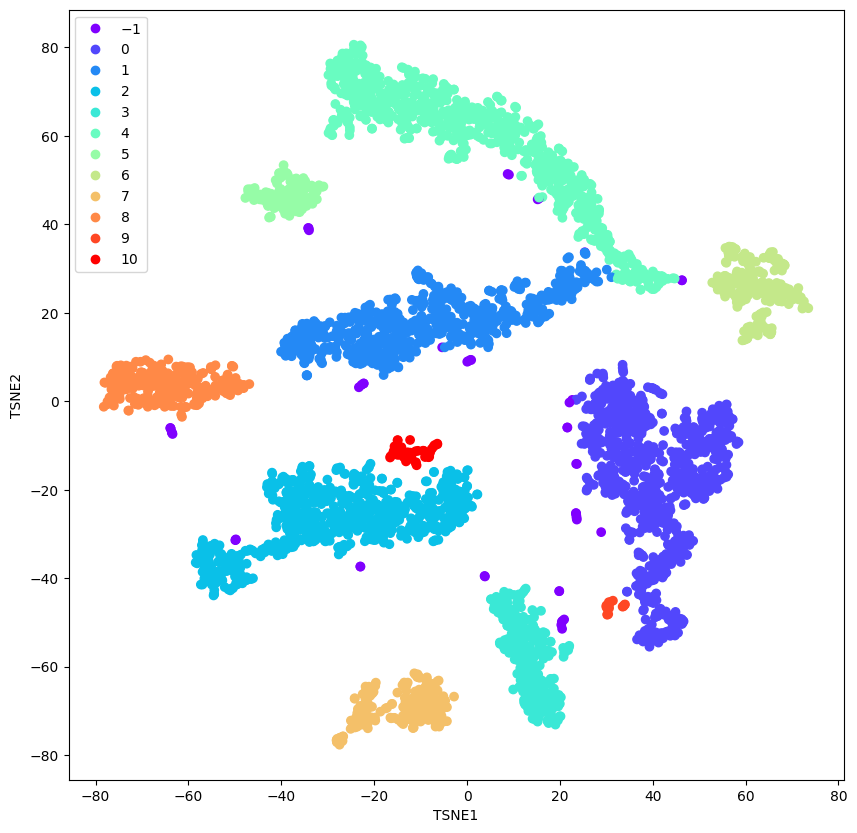

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

#Plot scatterplot for K-means Clustering
scatter = plt.scatter(tsne_em[:,0],tsne_em[:,1], c = dbscan_m.labels_, cmap ='rainbow')
plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.legend(*scatter.legend_elements())


This code snippet creates a scatter plot visualizing the results of the t-SNE transformation and DBSCAN clustering of your dataset. The plt.scatter function plots each point from the t-SNE transformed data (tsne_em) with colors representing the cluster labels assigned by DBSCAN (dbscan_m.labels_). The colors are determined by the 'rainbow' colormap. The x-axis and y-axis are labeled as 'TSNE1' and 'TSNE2', respectively. Finally, a legend is added using scatter.legend_elements() to differentiate the clusters based on color.


# **Practice Codes: Try it yourself**

### **Assignment 1:**
In this assignment, you will build upon your knowledge of Data visualization using t-SNE. The provided code is incomplete, with missing syntax and portions. Your task is to complete the code to successfully import data and plot tSNE . To complete this, use the following csv file: https://reneshbedre.github.io/assets/posts/tsne/ath_root_sub_seurat_processes.csv.

In [ ]:
import pandas as pd

df = df = pd.read_csv('/tsne/ath_root_sub_seurat_processes.csv')
df = df.set_index(df.columns[0])
dft = df.T
dft = dft.set_index(dft.columns[0])

# check data
dft.head()

FileNotFoundError: ignored

In [ ]:
# as we have large number variables, we will first do to PCA to keep minimum number
# of variables for t-SNE
from sklearn.decomposition import PCA
pca_scores = PCA().fit_transform()

# create a dataframe of pca_scores
df_pc = pd.DataFrame(pca_)

# perform t-SNE on PCs scores
# we will use first 50 PCs but this can vary
# see that "verbose=1" prints out parameters on execution

from sklearn.manifold import
tsne_em = TSNE(n_components=2, perplexity=30.0, early_exaggeration=12, n_iter=1000,
               learning_rate=368, verbose=1).fit_transform(df_pc.loc[:,0:49])


In [ ]:
from sklearn.cluster import DBSCAN
# here eps parameter is very important and optimizing eps is essential
# for well defined clusters. I have run DBSCAN with several eps values
# and got good clusters with eps=3
dbscan_m = DB(eps=3, min_samples=10).fit(tsne)


In [ ]:
#dbscan_m.labels_.tolist
clabels = dbscan_m.labels_.()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(fig=(10, 10))

#Plot scatterplot for K-means Clustering
scatter = plt.scatter(tsne[:,0],tsne_em[:,1], c = dbscan_m.labels_, cmap ='rainbow')
plt.xlabel('')
plt.ylabel('')
plt.legend(*scatter.legend_elements())